In [1]:
!pip install -q kaggle

In [2]:
mkdir kaggle

In [3]:
from pathlib import Path

kaggle_config = Path.home() / ".kaggle" / "kaggle.json"
print("Exists:", kaggle_config.exists())
print("Path:", kaggle_config)

Exists: False
Path: /root/.kaggle/kaggle.json


In [4]:
import os

os.environ['KAGGLE_USERNAME'] = 'mohammadmuneeb'
os.environ['KAGGLE_KEY'] = '4759bb72f02eec2980d47d5d29b1e2bc'

In [5]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:04<00:00, 210MB/s]  



In [6]:
import zipfile; 
zipfile.ZipFile('dogs-vs-cats.zip').extractall('.')

In [7]:
import zipfile; 
zipfile.ZipFile('train.zip').extractall('.')

In [8]:
import os, shutil, pathlib
original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

In [9]:
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg"
                  for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(
                src=original_dir / fname,
                dst=dir / fname
            )

In [10]:
make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

In [11]:
!pip install tensorflow
from tensorflow import keras
from tensorflow.keras import layers

In [12]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [15]:
from tensorflow.keras.utils import image_dataset_from_directory
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32
)

validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32
)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32
)


Found 2000 files belonging to 2 classes.


Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [16]:
for data_batch, labels_batch in train_dataset:
  print("data batch shape:", data_batch.shape)
  print("labels batch shape:", labels_batch.shape)
  break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


In [17]:
callbacks = [
 keras.callbacks.ModelCheckpoint(
 filepath="convnet_from_scratch.keras",
 save_best_only=True,
 monitor="val_loss")
]

In [18]:
history = model.fit(
 train_dataset,
 epochs=20,
 validation_data=validation_dataset,
 callbacks=callbacks)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.5305 - loss: 0.6964 - val_accuracy: 0.5250 - val_loss: 0.6913
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5140 - loss: 0.6958 - val_accuracy: 0.5300 - val_loss: 0.6854
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.5815 - loss: 0.6850 - val_accuracy: 0.6350 - val_loss: 0.6475
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.6135 - loss: 0.6566 - val_accuracy: 0.6490 - val_loss: 0.6217
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6600 - loss: 0.6298 - val_accuracy: 0.5400 - val_loss: 0.8375
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.6730 - loss: 0.5899 - val_accuracy: 0.6250 - val_loss: 0.6163
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.7105 - loss: 0.5569 - val_accuracy: 0.6840 - val_loss: 0.5715
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.7265 - loss: 0.5304 - val_accuracy: 0.7420 -

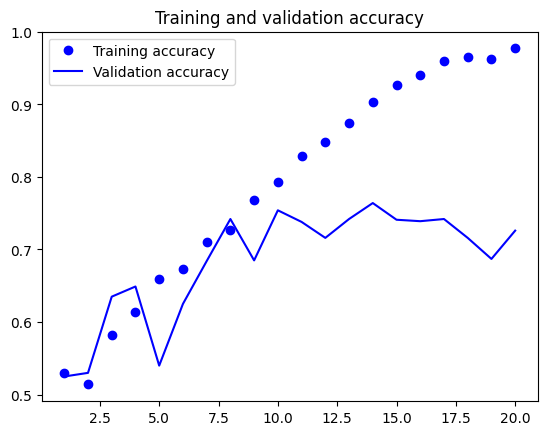

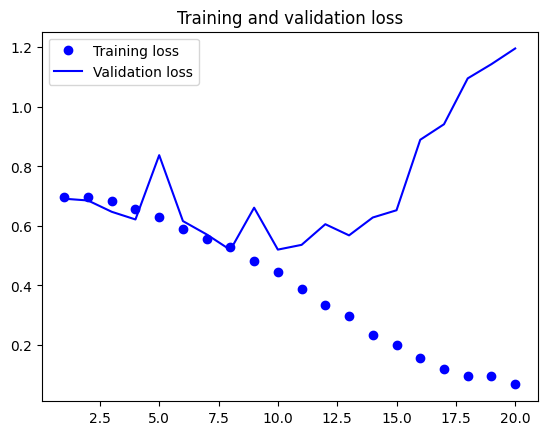

In [19]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [20]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc*100:.3f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.7280 - loss: 0.5435
Test accuracy: 72.800%


In [21]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [22]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [23]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [24]:
conv_base.trainable = False

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator,array_to_img, img_to_array, load_img

In [26]:
import os, shutil, pathlib
original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

In [27]:
def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg"
                  for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(
                src=original_dir / fname,
                dst=dir / fname
            )

In [28]:
make_subset("training", start_index=0, end_index=5000)
make_subset("testing", start_index=5000, end_index=10000)

In [29]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        'cats_vs_dogs_small/training',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        'cats_vs_dogs_small/testing',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 10000 images belonging to 2 classes.
Found 10000 images belonging to 2 classes.


In [30]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [31]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 404ms/step - accuracy: 0.8615 - loss: 0.3194 - val_accuracy: 0.8897 - val_loss: 0.2560
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 119s 379ms/step - accuracy: 0.8889 - loss: 0.2563 - val_accuracy: 0.9010 - val_loss: 0.2341
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 119s 380ms/step - accuracy: 0.9009 - loss: 0.2303 - val_accuracy: 0.9090 - val_loss: 0.2178
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 118s 378ms/step - accuracy: 0.9086 - loss: 0.2120 - val_accuracy: 0.9069 - val_loss: 0.2178
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 118s 376ms/step - accuracy: 0.9143 - loss: 0.2081 - val_accuracy: 0.9026 - val_loss: 0.2315
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 118s 378ms/step - accuracy: 0.9206 - loss: 0.1897 - val_accuracy: 0.8686 - val_loss: 0.3490
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 118s 376ms/step - accuracy: 0.9226 - loss: 0.1863 - val_accuracy: 0.9043 - val_loss: 0.2240
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 117s 374ms/step - accuracy: 0.9322 -

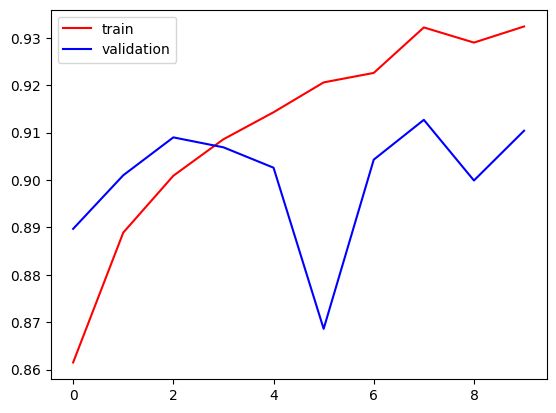

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

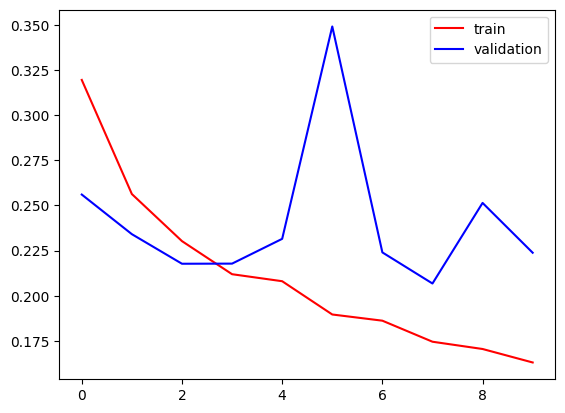

In [33]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()
     

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# If you restarted kernel, load saved model first:
# from tensorflow.keras.models import load_model
# model = load_model("convnet_from_scratch.keras")

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "cats_vs_dogs_small/test",   # use unseen test data
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Found 2000 images belonging to 2 classes.
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.9585 - loss: 0.1045
Test loss: 0.1045
Test accuracy: 0.9585


In [37]:
from sklearn.metrics import classification_report, confusion_matrix

probs = model.predict(test_generator, verbose=1).ravel()
preds = (probs >= 0.5).astype(int)
true_labels = test_generator.classes

print(confusion_matrix(true_labels, preds))
print(classification_report(true_labels, preds, target_names=["cat", "dog"]))

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step
[[979  21]
 [ 62 938]]
              precision    recall  f1-score   support

         cat       0.94      0.98      0.96      1000
         dog       0.98      0.94      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000

